   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 29.3 MB/s eta 0:00:00


Saving food detect.v17-no_augs.yolov8.zip to food detect.v17-no_augs.yolov8.zip
Dataset ready at: food detect.v17-no_augs.yolov8
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.17 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=food detect.v17-no_augs.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=Tr

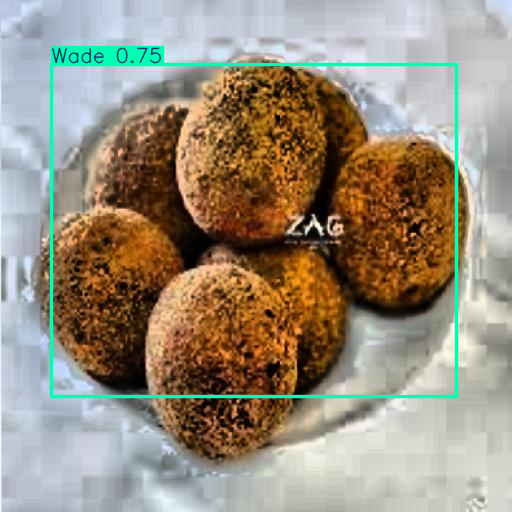

In [1]:
# Step 0: Install packages
!pip install ultralytics roboflow --quiet

# Step 1: Upload your dataset ZIP
from google.colab import files
uploaded = files.upload()  # choose your ZIP file

# Step 2: Unzip the dataset
import zipfile
import os
for fn in uploaded.keys():
    with zipfile.ZipFile(fn, 'r') as zip_ref:
        zip_ref.extractall(fn.replace(".zip",""))

dataset_path = fn.replace(".zip","")
print("Dataset ready at:", dataset_path)

# Step 3: Train a small YOLOv8 model quickly
from ultralytics import YOLO

# Use yolov8n.pt (nano) for very fast training
model = YOLO("yolov8s.pt")

# Quick training settings for testing
model.train(
    data=f"{dataset_path}/data.yaml",  # path to data.yaml
    epochs=40,                          # small number of epochs for fast start
    imgsz=640,                         # smaller images to speed up
    batch=4,                            # smaller batch for Colab free
    project="meal_plate_test",          # save results here
    name="quick_train",
    exist_ok=True,
    device=0
)

# Step 4: Test on one example image
example_image = os.path.join(dataset_path, "valid/images", os.listdir(os.path.join(dataset_path, "valid/images"))[0])
results = model.predict(example_image)
results[0].show()  # show the first (and only) result



Testing on: cake21_jpg.rf.e6a439d3d888bf06db130003afa73aaf.jpg

image 1/1 /content/food detect.v17-no_augs.yolov8/valid/images/cake21_jpg.rf.e6a439d3d888bf06db130003afa73aaf.jpg: 640x640 1 Sweets, 16.4ms
Speed: 3.0ms preprocess, 16.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


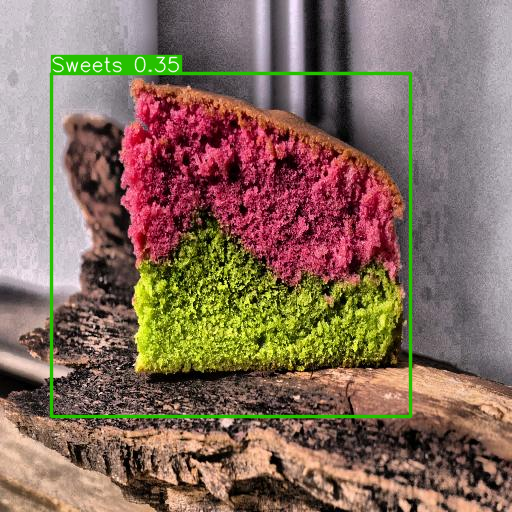

In [10]:
import random
import os

# Pick a random image from your validation set
valid_images_dir = os.path.join(dataset_path, "valid/images")
random_image = random.choice(os.listdir(valid_images_dir))
example_image = os.path.join(valid_images_dir, random_image)

print("Testing on:", random_image)
results = model.predict(example_image)
results[0].show()


Upload new meal plate images (you can select multiple):


Saving tt5.jpg to tt5.jpg
Saving tt6.webp to tt6.webp
Saving tt7.webp to tt7.webp
3 image(s) uploaded for testing.

--- Testing: new_food_images/tt5.jpg ---

image 1/1 /content/new_food_images/tt5.jpg: 448x640 1 Dhal Curry, 1 rice, 47.3ms
Speed: 3.1ms preprocess, 47.3ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/new_food_images/tt5.jpg: 448x640 1 Dhal Curry, 1 rice, 12.7ms
Speed: 1.9ms preprocess, 12.7ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)


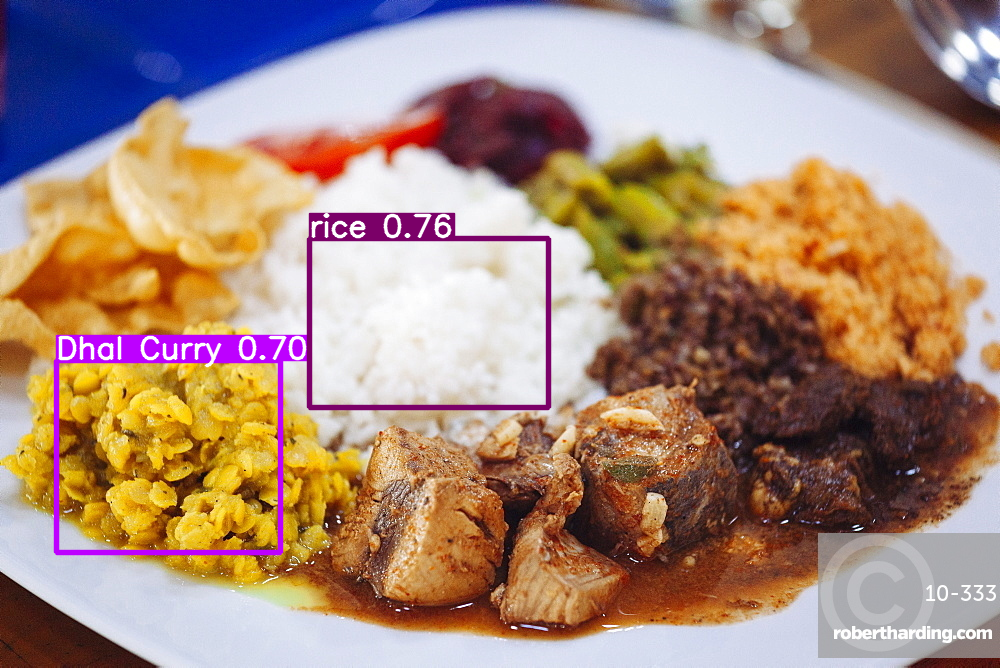

Detected foods:
  - rice, Confidence: 0.76
  - Dhal Curry, Confidence: 0.70

--- Testing: new_food_images/tt6.webp ---

image 1/1 /content/new_food_images/tt6.webp: 608x640 1 Carrot, 2 Gotukola Mallums, 1 Red rice, 1 rice, 75.0ms
Speed: 2.1ms preprocess, 75.0ms inference, 1.6ms postprocess per image at shape (1, 3, 608, 640)

image 1/1 /content/new_food_images/tt6.webp: 608x640 1 Carrot, 2 Gotukola Mallums, 1 Red rice, 1 rice, 16.0ms
Speed: 2.2ms preprocess, 16.0ms inference, 1.6ms postprocess per image at shape (1, 3, 608, 640)


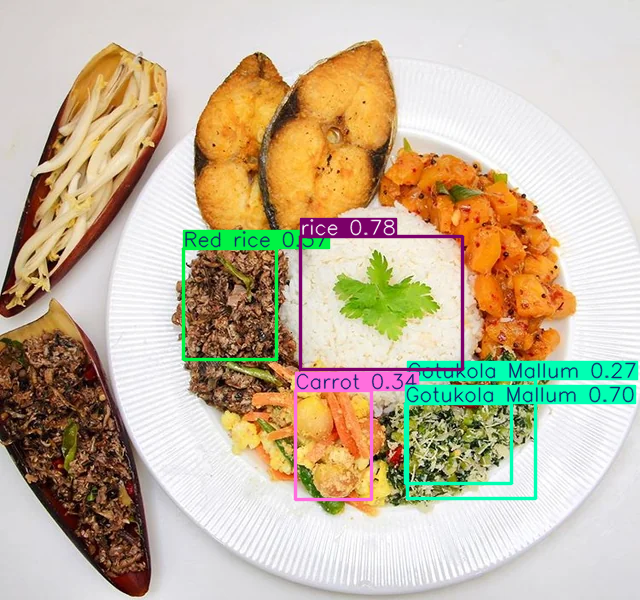

Detected foods:
  - rice, Confidence: 0.78
  - Gotukola Mallum, Confidence: 0.70
  - Red rice, Confidence: 0.37
  - Carrot, Confidence: 0.34
  - Gotukola Mallum, Confidence: 0.27

--- Testing: new_food_images/tt7.webp ---

image 1/1 /content/new_food_images/tt7.webp: 640x640 1 Dhal Curry, 2 Papadams, 2 rices, 17.6ms
Speed: 4.0ms preprocess, 17.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/new_food_images/tt7.webp: 640x640 1 Dhal Curry, 2 Papadams, 2 rices, 16.2ms
Speed: 4.0ms preprocess, 16.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


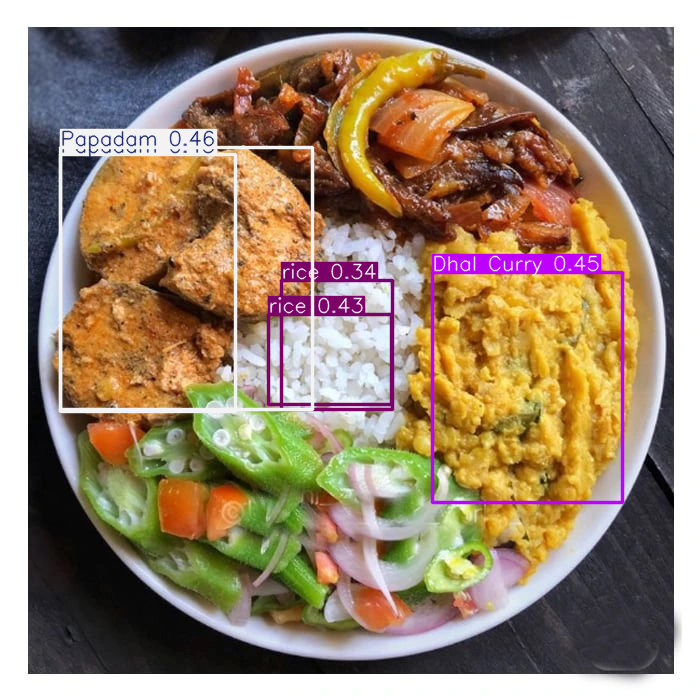

Detected foods:
  - Papadam, Confidence: 0.46
  - Papadam, Confidence: 0.45
  - Dhal Curry, Confidence: 0.45
  - rice, Confidence: 0.43
  - rice, Confidence: 0.34


In [11]:
# ==========================
# Cell 3: Test on new/unseen images
# ==========================

from ultralytics import YOLO
from google.colab import files
import os

# 1️⃣ Load your trained YOLOv8 model
model = YOLO("/content/runs/detect/meal_plate_test/quick_train/weights/best.pt")

# 2️⃣ Upload one or more new images (simulate user uploads)
print("Upload new meal plate images (you can select multiple):")
uploaded = files.upload()  # user selects image files

# 3️⃣ Create a folder to save uploaded images
os.makedirs("new_food_images", exist_ok=True)

# Save uploaded images
uploaded_files = []
for filename in uploaded.keys():
    path = os.path.join("new_food_images", filename)
    uploaded_files.append(path)
    with open(path, "wb") as f:
        f.write(uploaded[filename])
print(f"{len(uploaded_files)} image(s) uploaded for testing.")

# 4️⃣ Run predictions on each uploaded image
for img_path in uploaded_files:
    print("\n--- Testing:", img_path, "---")
    results = model.predict(img_path)  # Run YOLO detection

    # Show the image with bounding boxes
    results = model.predict(img_path)  # Run YOLO detection

    # Show the image with bounding boxes
    results[0].show()

    # Print detected foods with confidence scores
    print("Detected foods:")
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = model.names[class_id]
        print(f"  - {class_name}, Confidence: {confidence:.2f}")
